# Application: Drug Response

This tutorial demonstrates how STARNet-inferred gene regulatory networks (GRNs) can be combined with drug-target information to nominate spatially localized drug response patterns. We use the Fig6 TOPIRAMATE-HOXD4 example as a compact reference case and run the analysis on the data provided in `Drive`.

The goal is to keep the workflow easy to inspect: load the STARNet result, score drug target programs with drug2cell, compare the drug and TF signals across spatial domains, and visualize the overlap between drug targets and TF targets. Each plot type is shown once, and figures are displayed in the notebook instead of being saved to disk.

This tutorial uses STARNet for GRN-derived TF activity, drug2cell for drug-target scoring, Scanpy for AnnData handling and spatial plotting, and NetworkX for the target overlap network. Full citations are listed at the end of the notebook.


## Setup

We first import the packages used throughout the workflow. The helper functions are intentionally small: one converts gene symbols between mouse-style and human-style capitalization, and the other converts Scanpy's `rank_genes_groups` output into a tidy table.

The drug target database uses human gene symbols, while the mouse embryo STARNet output uses mouse gene symbols for TF activity. The simple capitalization helper is sufficient for the genes used in this tutorial and keeps the example focused on the workflow rather than on a full ortholog mapping step.


In [23]:
import os
import pickle as pkl
import sys
import warnings

import drug2cell as d2c
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import scanpy as sc
import seaborn as sns
import STARNet as ST

sys.path.append("./Drive/network")
from network_utils import get_network

warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore::FutureWarning"

sc.settings.set_figure_params(dpi=120, vector_friendly=True)
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


def transfer_gene_name(gene_names, direction="m2h"):
    if isinstance(gene_names, str):
        single_value = True
        gene_names = [gene_names]
    else:
        single_value = False

    if direction == "m2h":
        converted = [gene.upper() for gene in gene_names]
    elif direction == "h2m":
        converted = [gene.capitalize() for gene in gene_names]
    else:
        raise ValueError("direction must be 'm2h' or 'h2m'.")

    return converted[0] if single_value else converted


def ranked_genes_to_df(rank_genes_groups, n_genes=50):
    rows = []
    for group in rank_genes_groups["names"].dtype.names:
        for i in range(min(n_genes, len(rank_genes_groups["names"][group]))):
            rows.append(
                {
                    "group": group,
                    "drug": rank_genes_groups["names"][group][i],
                    "logfoldchanges": rank_genes_groups["logfoldchanges"][group][i],
                    "pvals_adj": rank_genes_groups["pvals_adj"][group][i],
                }
            )
    return pd.DataFrame(rows)


## Load Data

The input AnnData object contains the mouse embryo expression matrix together with STARNet GRN outputs in `.uns`. We extract the GRN score matrix from `adata.uns["grn"]["adata_nlog10_pval"]` and transpose it so that each spatial spot has TF scores available for plotting.

We then map Leiden clusters to the spatial domain labels used in the Fig6 example. These labels let us compare the drug response score and TF enrichment at the tissue-region level. Any unmapped cluster is assigned to `Other` so that downstream group-level statistics do not contain missing annotations.


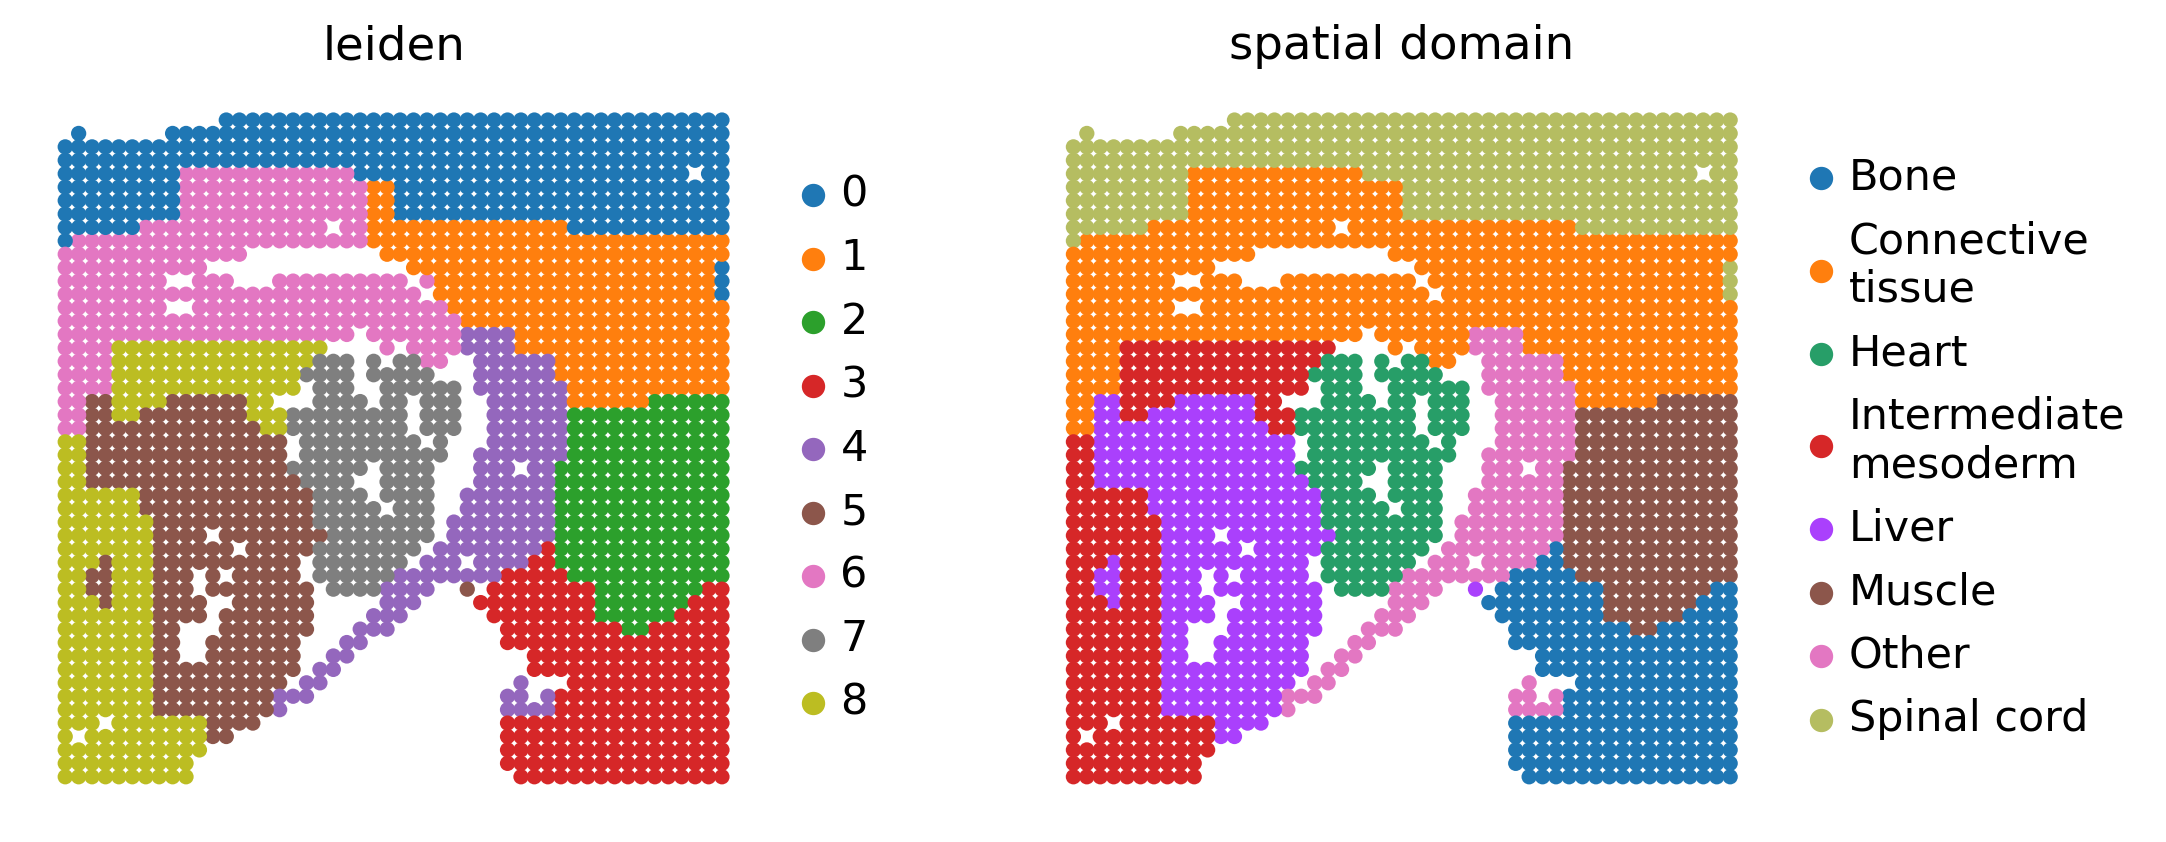

In [32]:
adata = sc.read_h5ad("Drive/Datasets/Mouse_Embryo/Process_Data/adata_rna_GRN.h5ad")
adata_grn = adata.uns["grn"]["adata_nlog10_pval"].T

cluster2annotation = {
    '0': 'Spinal cord',
    '1': 'Connective\ntissue',
    '2': 'Muscle',
    '3': 'Bone',
    '4': 'Other',
    '5': 'Liver',
    '6': 'Connective\ntissue',
    '7': 'Heart',
    '8': 'Intermediate\nmesoderm', 
}

adata.obs["spatial domain"] = adata.obs["leiden"].map(cluster2annotation).fillna("Other").astype("category")
adata_grn.obs["spatial domain"] = adata.obs["spatial domain"]

sc.pl.spatial(
    adata,
    color=["leiden", "spatial domain"],
    spot_size=50,
    frameon=False,
)


## Drug and TF Scores

drug2cell scores each spot by summarizing the expression of genes targeted by a drug. Here we first score all drug target sets so that TOPIRAMATE can be compared with other drugs in the same object. We then create a focused TOPIRAMATE-HOXD4 target set by intersecting TOPIRAMATE targets with HOXD4 target genes from the STARNet GRN.

This produces two complementary views: the full TOPIRAMATE target program and the subset of TOPIRAMATE targets that are also regulated by HOXD4. The overlap score is the key signal used for the Fig6-style drug-TF interpretation.


In [33]:
adata.var_names = transfer_gene_name(adata.var_names.to_list(), direction="m2h")
if adata.raw is not None:
    adata.raw._var.index = transfer_gene_name(adata.raw.var_names.to_list(), direction="m2h")

tf_gene_df = adata.uns["grn_df"].copy()
tf_gene_df["TF"] = tf_gene_df["TF"].str.upper()
tf_gene_df["target gene"] = tf_gene_df["target gene"].str.upper()
tf_target_dict = tf_gene_df.groupby("TF")["target gene"].apply(list).to_dict()

with open("Drive/drug2Cell/drug-target_dicts.pkl", "rb") as handle:
    raw_drug_target_dict = pkl.load(handle)

drug_target_dict = {}
for target_group in raw_drug_target_dict.values():
    drug_target_dict.update(target_group)

drug = "CHEMBL220492|TOPIRAMATE"
tf = "HOXD4"
tf_mouse = "Hoxd4"
drug_tf = f"{drug}_{tf}"
overlap_genes = sorted(set(drug_target_dict[drug]) & set(tf_target_dict[tf]))

print(f"{drug_tf}: {len(overlap_genes)} overlapping genes")
print(overlap_genes)

d2c.score(adata, use_raw=True)
adata.uns["drug2cell_all"] = adata.uns["drug2cell"].copy()

adata.uns["drug2cell_all"].obs["spatial domain"] = adata.obs["spatial domain"].values
sc.tl.rank_genes_groups(adata.uns["drug2cell_all"], method="wilcoxon", groupby="spatial domain")

d2c.score(adata, use_raw=True, targets={drug_tf: overlap_genes})
adata.uns["drug2cell_overlap"] = adata.uns["drug2cell"].copy()
adata.uns["drug2cell_overlap"].obs["spatial domain"] = adata.obs["spatial domain"].values
sc.tl.rank_genes_groups(adata.uns["drug2cell_overlap"], method="wilcoxon", groupby="spatial domain")


CHEMBL220492|TOPIRAMATE_HOXD4: 8 overlapping genes
['GABRB3', 'GABRG2', 'GRIA2', 'GRIK2', 'GRIK3', 'SCN1A', 'SCN3A', 'SCN9A']


## Spatial Enrichment

This panel mirrors the Fig6 plotting logic in a simplified form. The first map shows the STARNet-derived HOXD4 TF activity, the second map shows the TOPIRAMATE-HOXD4 overlap target score, and the third map shows the full TOPIRAMATE target score.

Viewing the three maps side by side helps distinguish a broad drug target signal from the subset of targets that are connected to a spatially enriched TF program.


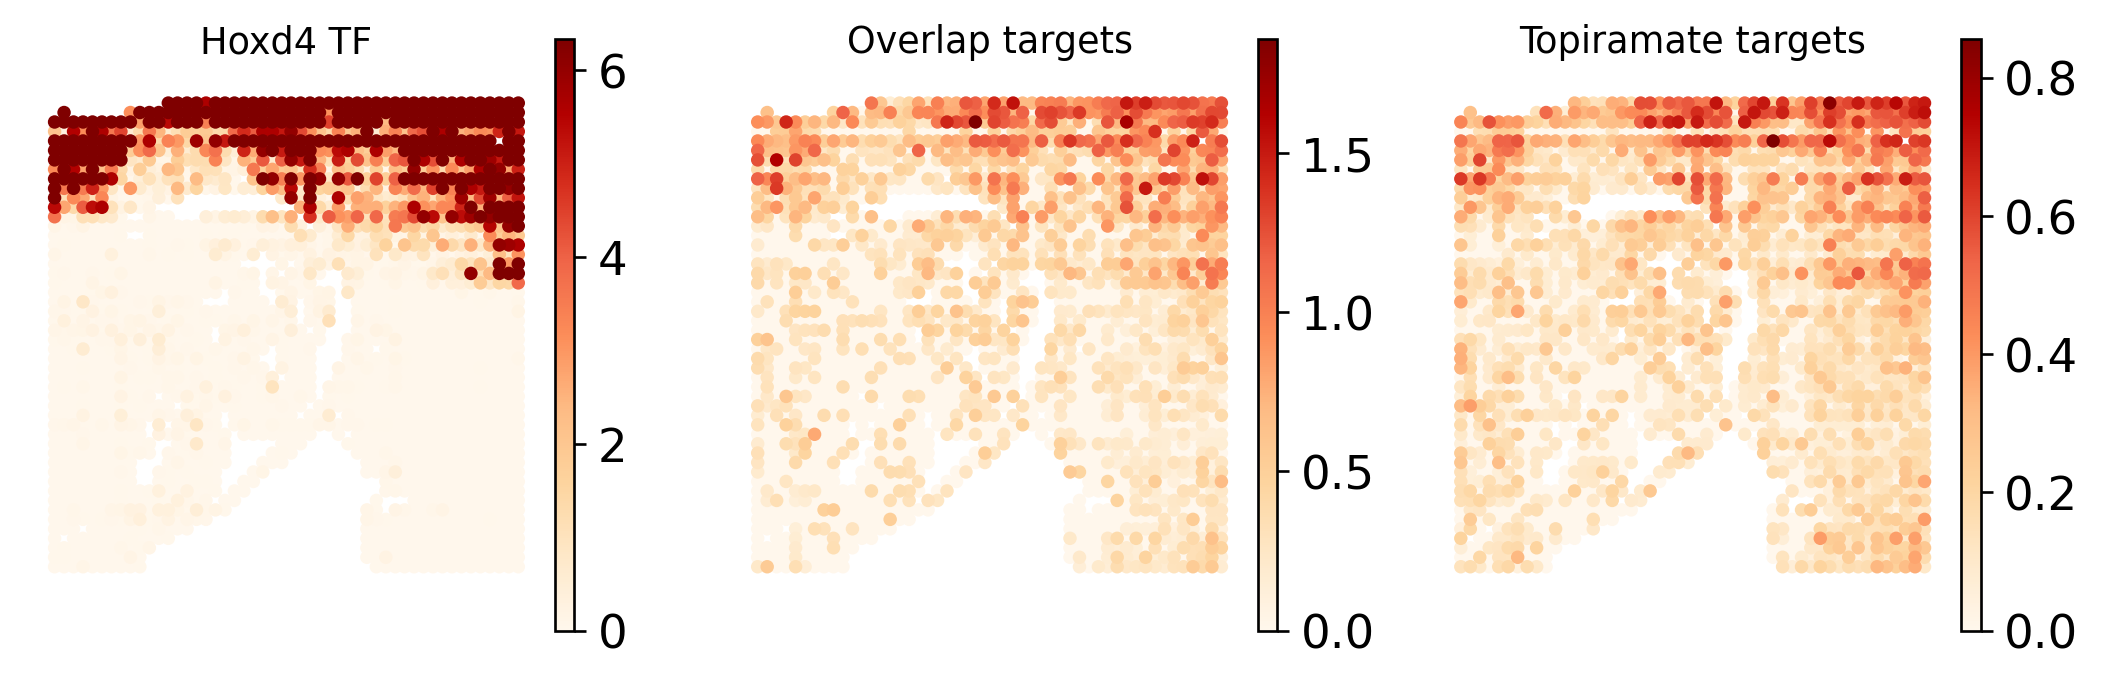

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

plot_specs = [
    (adata_grn, tf_mouse, f"{tf_mouse} TF"),
    (adata.uns["drug2cell_overlap"], drug_tf, "Overlap targets"),
    (adata.uns["drug2cell_all"], drug, "Topiramate targets"),
]

for ax, (plot_adata, color, title) in zip(axes, plot_specs):
    sc.pl.spatial(
        plot_adata,
        color=color,
        spot_size=62.5,
        color_map="OrRd",
        ax=ax,
        show=False,
        frameon=False,
    )
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.show()


## Region Heatmap

The region-level heatmaps follow the Fig6 definitions. For TOPIRAMATE, we use drug2cell GSEA and plot the normalized enrichment score (NES) across spatial domains. For HOXD4, we use STARNet's Cauchy combination test and plot the aggregated `-log10(P)` TF enrichment across the same domains.

These two values have different meanings and ranges, so they are shown as two heatmaps within one figure rather than forced into a shared color scale. The expected Fig6-consistent pattern is that both TOPIRAMATE and HOXD4 are strongest in the spinal cord domain.


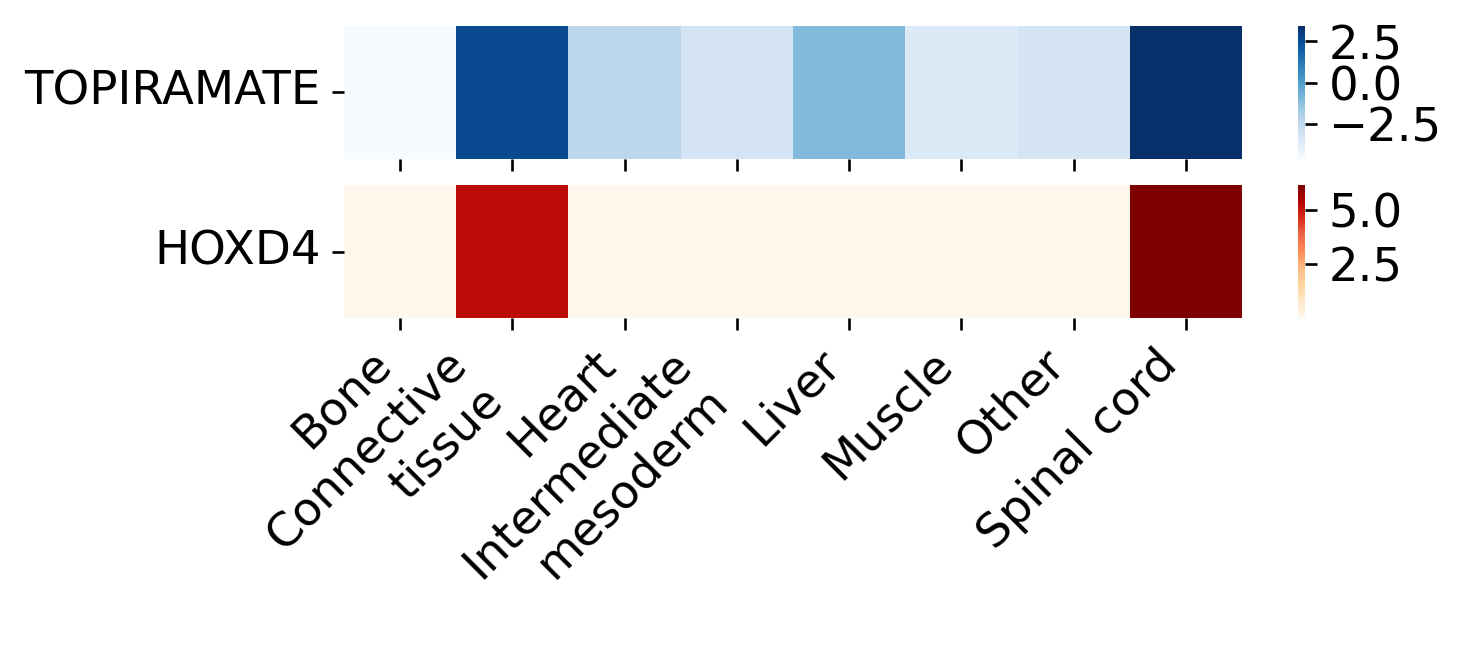

In [40]:
# Drug and TF scores across spatial domains
sc.tl.rank_genes_groups(adata, method="wilcoxon", groupby="spatial domain")

drug_gsea, _ = d2c.gsea(adata, targets=drug_target_dict)

drug_score = pd.Series(
    {k: v.loc[drug, "nes"] for k, v in drug_gsea.items() if drug in v.index},
    name="TOPIRAMATE"
)

tf_score = (
    ST.pp.cal_cauchy_combination_test(adata, annotation_col="spatial domain")
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .loc[tf_mouse]
    .rename("HOXD4")
)

domains = adata.obs["spatial domain"].cat.categories

fig, axes = plt.subplots(2, 1, figsize=(6, 1.6), sharex=True)

sns.heatmap(pd.DataFrame([drug_score.loc[domains]]), cmap="Blues", linewidths=0, ax=axes[0])
sns.heatmap(pd.DataFrame([tf_score.loc[domains]]), cmap="OrRd", linewidths=0, ax=axes[1])

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.grid(False)

axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Target Overlap Network

The network view shows how TOPIRAMATE targets and HOXD4 targets relate within the human protein interaction network. Nodes are colored by whether they are drug targets, TF targets, or shared overlap targets.

This plot is intentionally minimal. It only highlights the overlap genes and avoids additional layout options so that the tutorial stays focused on the biological interpretation rather than figure tuning.


Shrinking network to its LCC: 15970 nodes, 217160 edges
Final shape: 15911 nodes, 217109 edges


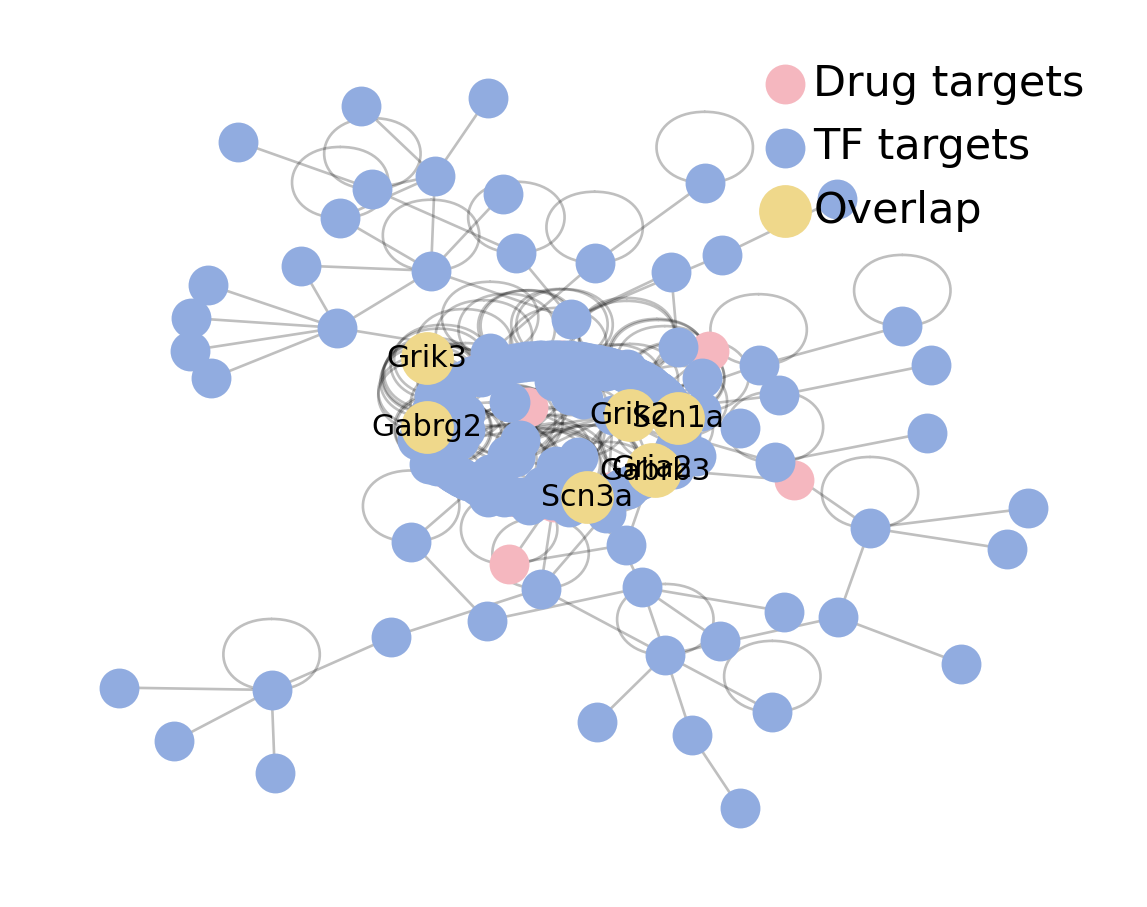

In [36]:
def plot_overlap_network(graph, drug_nodes, tf_nodes, id_to_symbol):
    drug_nodes = set(drug_nodes) & set(graph.nodes)
    tf_nodes = set(tf_nodes) & set(graph.nodes)
    focus_nodes = drug_nodes | tf_nodes
    if not focus_nodes:
        raise ValueError("No target genes were found in the network.")

    subgraph = graph.subgraph(focus_nodes).copy()
    pos = nx.kamada_kawai_layout(subgraph) if subgraph.number_of_edges() else nx.spring_layout(subgraph, seed=0)
    overlap_nodes = drug_nodes & tf_nodes

    fig, ax = plt.subplots(figsize=(5, 4))
    nx.draw_networkx_edges(subgraph, pos, ax=ax, alpha=0.25, width=0.8)
    nx.draw_networkx_nodes(subgraph, pos, nodelist=list(drug_nodes - overlap_nodes), node_color="#F5B7BF", node_size=120, ax=ax, label="Drug targets")
    nx.draw_networkx_nodes(subgraph, pos, nodelist=list(tf_nodes - overlap_nodes), node_color="#91ACE0", node_size=120, ax=ax, label="TF targets")
    nx.draw_networkx_nodes(subgraph, pos, nodelist=list(overlap_nodes), node_color="#EFD88B", node_size=220, ax=ax, label="Overlap")

    labels = {node: transfer_gene_name(id_to_symbol.get(node, node), direction="h2m") for node in overlap_nodes}
    nx.draw_networkx_labels(subgraph, pos, labels=labels, font_size=9, ax=ax)
    ax.legend(frameon=False, loc="best")
    ax.axis("off")
    plt.tight_layout()
    return fig, ax


gene_info_df = pd.read_csv("Drive/network/data/Homo_sapiens.gene_info", sep="	", dtype=str)
symbol_to_id = dict(zip(gene_info_df["Symbol"], gene_info_df["GeneID"]))
id_to_symbol = dict(zip(gene_info_df["GeneID"], gene_info_df["Symbol"]))

drug_target_ids = [symbol_to_id[gene] for gene in drug_target_dict[drug] if gene in symbol_to_id]
tf_target_ids = [symbol_to_id[gene] for gene in tf_target_dict[tf] if gene in symbol_to_id]

network = get_network("Drive/network/data/human_interactome.sif", only_lcc=True)
network = network.copy()
if "7316" in network:
    network.remove_node("7316")

fig, ax = plot_overlap_network(network, drug_target_ids, tf_target_ids, id_to_symbol)
plt.show()


## Candidate Table

Finally, we convert the ranked drug response output into a table and inspect the top spinal cord entries. This is a practical checkpoint: after visualizing a selected example, the ranked table shows how the same drug scoring result can be queried for additional candidate drugs or spatial domains.


In [37]:
ranked_drugs = ranked_genes_to_df(adata.uns["drug2cell_all"].uns["rank_genes_groups"], n_genes=20)
ranked_drugs[ranked_drugs["group"] == "Spinal cord"].head(10)


,group,drug,logfoldchanges,pvals_adj
140,Spinal cord,CHEMBL220492|TOPIRAMATE,1.589597,1.190744e-68
141,Spinal cord,CHEMBL1201023|ORPHENADRINE HYDROCHLORIDE,1.875208,2.466036e-59
142,Spinal cord,CHEMBL3989949|CENOBAMATE,1.723118,3.017646e-50
143,Spinal cord,CHEMBL856|PRIMIDONE,1.685417,6.901183e-50
144,Spinal cord,CHEMBL2068724|ACAMPROSATE CALCIUM,1.686530,3.044813e-49
145,Spinal cord,CHEMBL1201022|PHENAZOPYRIDINE HYDROCHLORIDE,1.638349,5.806359e-47
146,Spinal cord,CHEMBL4298209|BELANTAMAB MAFODOTIN,1.302020,2.441969e-45
147,Spinal cord,CHEMBL1742994|BRENTUXIMAB VEDOTIN,1.302020,2.441969e-45
148,Spinal cord,CHEMBL3301582|POLATUZUMAB VEDOTIN,1.302020,2.441969e-45
149,Spinal cord,CHEMBL2110725|VINFLUNINE,1.302020,2.441969e-45


## References

Please cite the relevant tools and resources when using this workflow:

- STARNet: Hu L, Zhang S, Zhang X, Luo Y, Gu H, Liu P, Mao S, Chen L, Xia Y, Yang M, Zhang S, Min Y, Li H, Wang P, Yu H, Zeng J. STARNet enables spatially resolved inference of gene regulatory networks from spatial multi-omics data. bioRxiv. 2025. doi: 10.1101/2025.08.21.671434.
- drug2cell: Kanemaru K, Cranley J, Muraro D, et al. Spatially resolved multiomics of human cardiac niches. Nature 619, 801-810 (2023). doi: 10.1038/s41586-023-06311-1.
- Scanpy: Wolf FA, Angerer P, Theis FJ. SCANPY: large-scale single-cell gene expression data analysis. Genome Biology 19, 15 (2018). doi: 10.1186/s13059-017-1382-0.
- NetworkX: Hagberg AA, Schult DA, Swart PJ. Exploring network structure, dynamics, and function using NetworkX. Proceedings of the 7th Python in Science Conference, 11-15 (2008).
